In [1]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from george import kernels
import george
import scipy.optimize as op
import os, sys
other_folder_path = os.path.abspath('./../')
# Add the directory to sys.path
if other_folder_path not in sys.path:
    sys.path.append(other_folder_path)
from functions import *
from gp_model_params import info
from pathlib import Path
from glob import glob

/Users/somayeh/opt/anaconda3/envs/pyt313/lib/python3.13/site-packages/george/metrics.py:103: RuntimeWarning: divide by zero encountered in log
  parameters.append(np.log(metric))


In [2]:
# Define home directory
home = str(Path.home())

In [3]:
Roman_sampling_short = np.load('./../lc_example/roman_times_shortcadence.npy')
Roman_sampling_long = np.load('./../lc_example/roman_times_longcadence.npy')
Roman_sampling_short_min = min(Roman_sampling_short)
Roman_sampling_short = Roman_sampling_short - Roman_sampling_short_min
Roman_sampling_long_min = min(Roman_sampling_long)
Roman_sampling_long = Roman_sampling_long - Roman_sampling_long_min
Roman_max_short_time = max(Roman_sampling_short)
max_time_regular = 2000 # One of the produced resampled light curves will have a baseline of 2000 days.

In [4]:
def der(xy):
    """
    Compute the numerical derivative of a function given y-values and their corresponding x-values.

    Parameters
    ----------
    xy : array-like, shape (2, N)
        A two-element list or array where:
        - xy[0] contains the y-values,
        - xy[1] contains the corresponding x-values.

    Returns
    -------
    ndarray, shape (2, N-1)
        A two-row array:
        - Row 0: dy/dx (the finite difference derivative),
        - Row 1: midpoints of x (used as the new x positions of the derivative).
    """
    xder, yder = xy[1], xy[0]
    return np.array([np.diff(yder) / np.diff(xder), xder[:-1] + np.diff(xder) * 0.5])


def smoothness_gen(x, y, gp):
    """
    Generate a smoothness penalty term from a GP-predicted function.

    This function applies a second derivative estimate to a Gaussian Process (GP)
    prediction of y-values at positions x, and computes a scalar penalty measuring
    the total curvature or roughness of the prediction.

    Parameters
    ----------
    x : ndarray
        Input x-values.
    y : ndarray
        Observed y-values.
    gp : george.GP
        A Gaussian Process object from the `george` package.

    Returns
    -------
    float
        The total smoothness penalty, computed as the sum of the absolute
        second derivative values of the GP-predicted curve.
    """
    return np.nansum(np.abs(der(der([gp.predict(y, x)[0], x]))), axis=1)[0]
    
def nll(p, y, x, gp, s):
    """
    Compute the negative log-likelihood (NLL) with a smoothness regularization term.

    The function sets the GP kernel parameters, evaluates the likelihood of the
    data under the GP model, and penalizes non-smooth predictions using a tunable
    power-law penalty on second derivatives.

    Parameters
    ----------
    p : ndarray
        The kernel hyperparameter vector to set in the GP.
    y : ndarray
        The observed data values.
    x : ndarray
        The x-values corresponding to `y`.
    gp : george.GP
        A Gaussian Process object from the `george` package.
    s : float
        Smoothness exponent; larger values increase the penalty on rough solutions.

    Returns
    -------
    float
        The negative log-likelihood, regularized by the smoothness term.
        Returns a large penalty (1e25) if numerical instability or NaN is encountered.
    """
    gp.kernel.parameter_vector = p

    try:
        smoothness = smoothness_gen(x, y, gp)
        smoothness = smoothness if np.isfinite(smoothness) \
                                   and ~np.isnan(smoothness) else 1e25
    except np.linalg.LinAlgError:
        smoothness = 1e25

    ll = gp.log_likelihood(y, quiet=True)  # - (smoothness) #np.sum((y - pred[inds]**2)) #
    ll -= smoothness ** s

    # print('smoothness is ', smoothness)

    # print (p, -ll if np.isfinite(ll) else 1e25)
    return -ll if np.isfinite(ll) else 1e25

In [5]:
tp = 'CV_mine'
file_format = '.dat'
id_ = '0001'

In [6]:
# Set directory paths and read period data
direc = home+'/Research_data/Bulge_Variables/%s/phot/'%tp
direc_list = np.sort(glob(direc+'*'+file_format))
if not tp == 'CV_mine':
    list_periods = np.genfromtxt(home+'/Research_data/Bulge_Variables/%s/BLG_%s_OGLE_periods.txt'%(tp,tp), dtype='str')
    n_phs_original = info[tp]['n_phs']

In [7]:
direc_list

array(['/Users/somayeh/Research_data/Bulge_Variables/CV_mine/phot/OGLE-BLG-DN-0001.dat',
       '/Users/somayeh/Research_data/Bulge_Variables/CV_mine/phot/OGLE-BLG-DN-0002.dat',
       '/Users/somayeh/Research_data/Bulge_Variables/CV_mine/phot/OGLE-BLG-DN-0003.dat',
       ...,
       '/Users/somayeh/Research_data/Bulge_Variables/CV_mine/phot/OGLE-MC-DN-0030.dat',
       '/Users/somayeh/Research_data/Bulge_Variables/CV_mine/phot/OGLE-MC-DN-0031.dat',
       '/Users/somayeh/Research_data/Bulge_Variables/CV_mine/phot/OGLE-MC-DN-0032.dat'],
      shape=(1091,), dtype='<U78')

In [11]:
# Reading an example light curve of a CV
path0 = direc_list[1]
t, m, merr = np.loadtxt(path0, unpack=True)

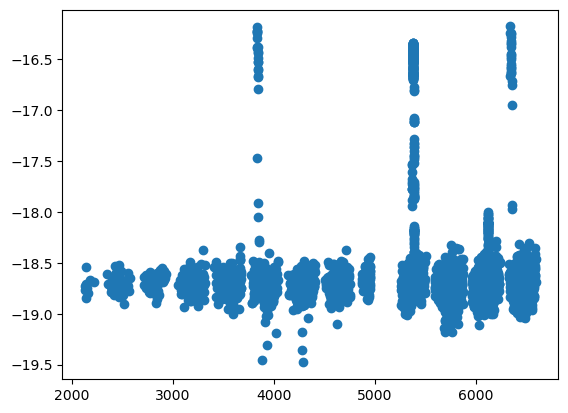

In [12]:
plt.scatter(t, -m)
# plt.xlim(-1,2000)

In [13]:
df = pd.DataFrame({'t': t, 
                    'm': m,
                    'e': merr,
                    'phase': merr,
                     'band': ['I']*len(t)})

In [14]:
period, df_ = read_fits(path, period=period,
                       tp = tp)

if np.isnan(period):
    pass

all_templates[ID] = {}

for i, band in enumerate(bands):
    print('Reading %s band'%band)

    if all_bands:
        if i>0 and np.sum(flags) != 0:
            flags[i] = 1
            print('Error: All_bands is on. %s was removed because one band is missing.'%ID)
            continue
    try:
        df = df_[df_.band==band]
    except AttributeError:
        flags[i] = 1
        print('Error: %s band does not exit. Skipping...'%band)
        continue

    if len(df)<10:
        flags[i] = 1 
        print('Error: Found less than 10 datapoints. Skipping...')
        continue

    df = df.reset_index(drop=True)

NameError: name 'path' is not defined

In [15]:
period = np.nan

In [16]:
df_modified = prep_for_fit(df, np.nan, info['CV'])

In [17]:
gp = prep_gp(info['CV'], period=np.nan)
# x, y, e are either the full lc or an intrval of n phases of them conducted by repeating a folded phase n times
x, y, e = prep_input(df_modified, tp, period, info['CV'], Roman_max_short_time)

In [18]:
# Defining the GP kernel
kernel = kernels.Product(kernels.ConstantKernel(1.10), kernels.Matern32Kernel(5.0))
#kernels.Product(kernels.ConstantKernel(1.10), kernels.ExpSquaredKernel(1.73))
gp = george.GP(kernel)

In [19]:
# Isolating a single peak in the light curve
t0 = 3500
ind_fit = ((t - t0)<2000) & ((t - t0)>0)
t_fit = (t- t0) [ind_fit]
m_fit = m[ind_fit]
err_fit = merr[ind_fit]
# res_fit = residuals[ind_fit]

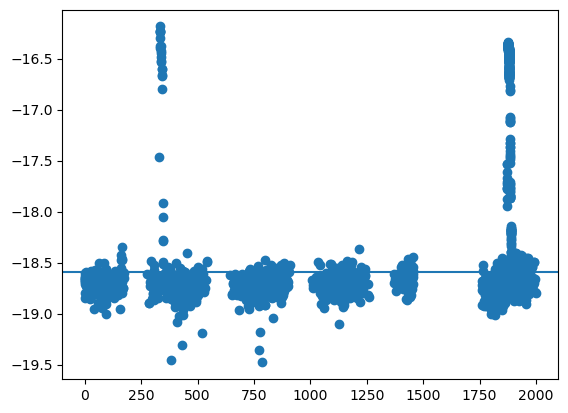

In [20]:
plt.scatter(t_fit, -m_fit)
plt.axhline(-1*np.percentile(m_fit, 20))
# plt.xlim(-1,2000)

NameError: name 's' is not defined

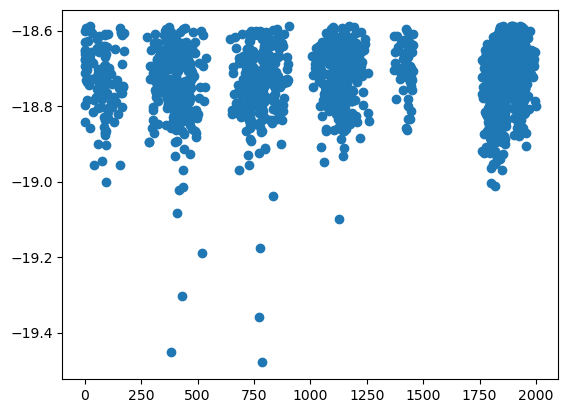

In [73]:
from scipy.interpolate import UnivariateSpline
def ssqe(sm, s, npts):
    return np.sqrt(np.sum(np.power(s-sm, 2))) / npts
def testSpline(x, y, s, npts):
    sp = UnivariateSpline(x, y, s=240)
    plt.plot(x,sp(x))
    print ("splerr", ssqe(sp(x), s, npts))
    return sp(x)
plt.scatter(t_fit[-m_fit<-1*np.percentile(m_fit, 20)], -m_fit[-m_fit<-1*np.percentile(m_fit, 20)])
new_m =testSpline(x, y, s, npts) 
plt.scatter(t_fit[-m_fit<-1*np.percentile(m_fit, 20)], -m_fit[-m_fit<-1*np.percentile(m_fit, 20)])

plt.axhline(np.median (-m_fit[-m_fit<-1*np.percentile(m_fit, 20)]))

In [74]:
new_lc = np.zeros(len(m_fit))
new_lc[-m_fit<-1*np.percentile(m_fit, 20)] = np.median(m_fit[-m_fit<-1*np.percentile(m_fit, 20)])
new_lc[-m_fit>=-1*np.percentile(m_fit, 20)] = m_fit[-m_fit>=-1*np.percentile(m_fit, 20)]

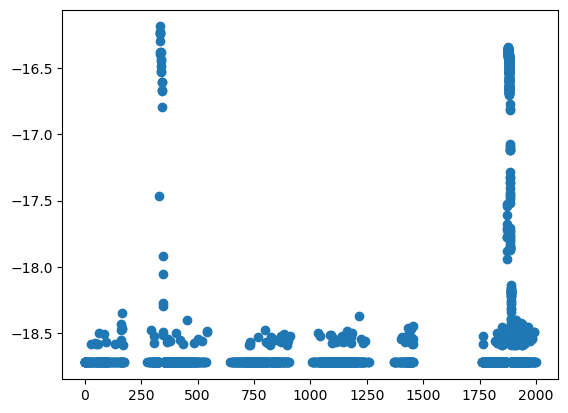

In [75]:
plt.scatter(t_fit, -new_lc)


In [22]:
x_binned, y_binned, e_binned, regular_sampling_fit = binning_data(t_fit, 
                                                                  m_fit, 
                                                                  err_fit,
                                                                  info['CV'],
                                                                  n_bins=1500)

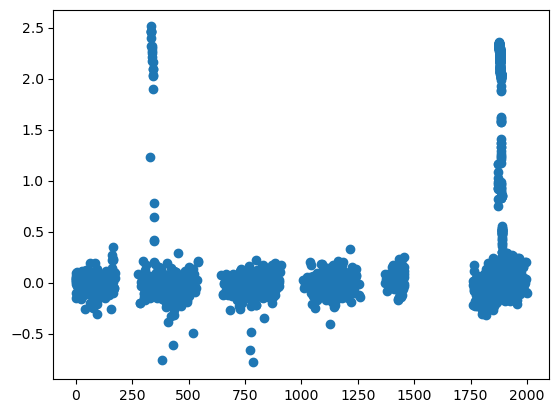

In [85]:
plt.scatter(x_binned, -1*y_binned)

In [23]:
x_binned = x_binned[~np.isnan(e_binned)]
y_binned = y_binned[~np.isnan(e_binned)]
e_binned = e_binned[~np.isnan(e_binned)]

<ErrorbarContainer object of 3 artists>

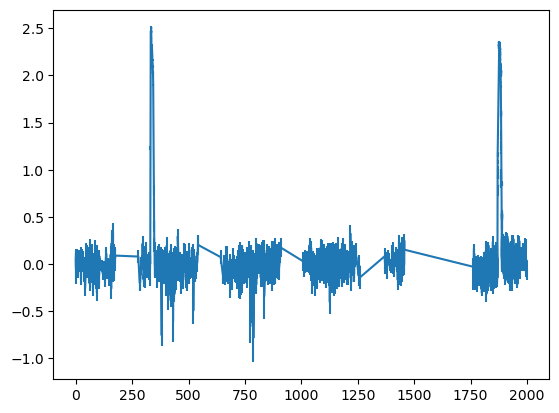

In [24]:
plt.errorbar(x_binned, -1*y_binned, yerr=e_binned)

In [25]:
sum(np.isnan(x_binned))

np.int64(0)

In [26]:
gp.compute(x_binned, 
           e_binned)

In [27]:
gp = fit_gp(x_binned, y_binned, e_binned, info['CV'], gp)

ValueError: array must not contain infs or NaNs

In [ ]:
# Optimizing parameters of the GP
# s determines the smoothness of the fit, larger s= smoother curve
gp.compute(x_binned, e_binned)
p0 = gp.kernel.parameter_vector
s = 2
results = op.minimize(nll, [p0[0], p0[1]],
                      args=(y_binned-np.median(y_binned),
                            x_binned, gp, s))
# Update the kernel and print the final log-likelihood.
gp.kernel.parameter_vector = results.x

In [ ]:
# Predicting on a new time sampling

t_fit_new = np.linspace(0,2000, 2000)
model_interp_new = model_interp(t_fit_new)
mu, cov = gp.predict(y_binned-np.median(y_binned), t_fit_new)
std = np.sqrt(np.diag(cov))

In [ ]:
gp.kernel.parameter_vector

Text(0, 0.5, 'Magnitude')

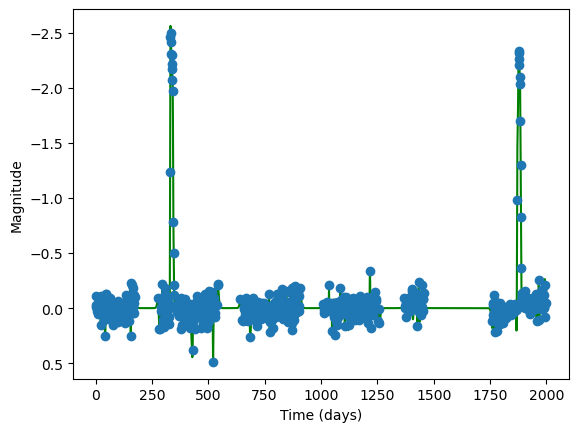

In [85]:
plt.errorbar(x_binned, y_binned-np.median(y_binned), yerr=e_binned, fmt='o', label='Data')
plt.plot(t_fit_new, mu, color='g', label='GP fit')

plt.gca().invert_yaxis()

plt.xlabel('Time (days)')
plt.ylabel('Magnitude')
# plt.xlim(1000,1100)